In [50]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.decomposition import PCA


In [51]:
df=pd.read_csv("house_missing_val.csv")

In [52]:
df = df[df['price'] < df['price'].quantile(0.90)]

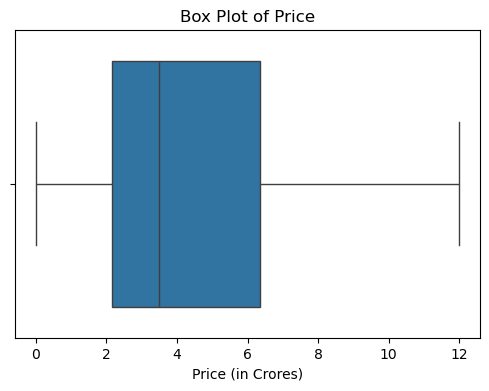

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])
plt.title('Box Plot of Price')
plt.xlabel('Price (in Crores)')
plt.show()

In [54]:
df.shape

(17965, 29)

In [55]:
drop_cols = [
  'rooms',
  'link',                     # useless identifier
    'society',                  # you chose not to use location
    'area',                     # already converted to area_sqft
    'servant_quarters_flag',    # duplicate info
    'store_rooms_flag',         # duplicate info
    'kitchens_flag',            # duplicate info
    'other_rooms',               # raw / vague
    'price_per_sqft',
    'study_room',
    'steam_room',
    'lounge_or_sitting_room',
    'powder_room',
    'prayer_room',
    'laundry_room',
    'drawing_room',
    'dining_room'
]

df=df.drop(columns=drop_cols)

In [56]:
df.columns

Index(['bedrooms', 'baths', 'floors', 'price', 'area_sqft', 'kitchens',
       'store_rooms', 'gym', 'luxury_score', 'furnishing_score',
       'agePossession', 'has_servant_room'],
      dtype='object')

In [57]:
def categorize_luxury(score):
    if score < 120:
        return "Low"
    elif 120 <= score < 155:
        return "Medium"
    elif 155 <= score < 175:
        return "High"
    else:
        return "Very High"
    
    
q1 = df['luxury_score'].quantile(0.25)
q2 = df['luxury_score'].quantile(0.50)
q3 = df['luxury_score'].quantile(0.75)

def categorize_luxury(score):
    if score < q1:
        return "Low"
    elif score < q2:
        return "Medium"
    elif score < q3:
        return "High"
    else:
        return "Very High"


In [58]:
df['luxury_category'] = df['luxury_score'].apply(categorize_luxury)

In [59]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif floor >= 11:
        return "High Floor"
    else:
        return None

df['floor_category'] = df['floors'].apply(categorize_floor)

In [60]:
df.drop(columns=['floors', 'luxury_score'], inplace=True)

In [61]:
df.head()

,bedrooms,baths,price,area_sqft,kitchens,store_rooms,gym,furnishing_score,agePossession,has_servant_room,luxury_category,floor_category
1,6.0,7.0,11.50,5445.02,3.0,2.0,1,25,New Property,1,Very High,Low Floor
3,5.0,6.0,9.25,5445.02,3.0,1.0,1,25,New Property,1,Very High,Low Floor
4,5.0,6.0,7.15,5445.02,1.0,1.0,1,25,New Property,1,Very High,Low Floor
5,5.0,6.0,6.95,5445.02,3.0,2.0,1,25,New Property,1,Very High,Low Floor
6,4.0,5.0,4.50,2722.51,2.0,1.0,0,13,New Property,1,Medium,Low Floor


In [62]:
df.shape

(17965, 12)

In [63]:
df['furnishing_score'].value_counts()

furnishing_score
25    8083
15    3209
0     1527
24     705
14     620
5      457
7      401
8      368
6      365
3      322
11     282
13     272
12     244
10     165
1      125
2      123
23     115
9      100
20      94
4       93
22      70
16      62
18      56
17      46
21      40
19      21
Name: count, dtype: int64

In [64]:
df['furnishing_type'] = pd.cut(
    df['furnishing_score'],
    bins=[-1, 0, 10, 25, 100],
    labels=[
        'Unfurnished',
        'Semi-Furnished',
        'Furnished',
        'Luxury Furnished'
    ]
)

In [65]:
df=df.drop(columns='furnishing_score')

In [66]:
df.head()

,bedrooms,baths,price,area_sqft,kitchens,store_rooms,gym,agePossession,has_servant_room,luxury_category,floor_category,furnishing_type
1,6.0,7.0,11.50,5445.02,3.0,2.0,1,New Property,1,Very High,Low Floor,Furnished
3,5.0,6.0,9.25,5445.02,3.0,1.0,1,New Property,1,Very High,Low Floor,Furnished
4,5.0,6.0,7.15,5445.02,1.0,1.0,1,New Property,1,Very High,Low Floor,Furnished
5,5.0,6.0,6.95,5445.02,3.0,2.0,1,New Property,1,Very High,Low Floor,Furnished
6,4.0,5.0,4.50,2722.51,2.0,1.0,0,New Property,1,Medium,Low Floor,Furnished


In [67]:
# Rename columns
df.rename(columns={
    'gym': 'is_gym',
    'has_servant_room': 'is_servant_room'
}, inplace=True)

df['is_gym'] = df['is_gym'].map({1: 'Yes', 0: 'No'})
df['is_servant_room'] = df['is_servant_room'].map({1: 'Yes', 0: 'No'})

In [68]:
df.columns

Index(['bedrooms', 'baths', 'price', 'area_sqft', 'kitchens', 'store_rooms',
       'is_gym', 'agePossession', 'is_servant_room', 'luxury_category',
       'floor_category', 'furnishing_type'],
      dtype='object')

In [69]:
df['bedrooms'].value_counts()

bedrooms
5.0     6645
3.0     4813
4.0     4021
6.0     1690
7.0      362
2.0      278
1.0       67
8.0       65
9.0       12
10.0      10
11.0       2
Name: count, dtype: int64

In [70]:
df['baths'].value_counts()

baths
6.0     6387
4.0     4839
5.0     4015
3.0     1299
7.0     1065
2.0      249
1.0       71
8.0       22
9.0       10
10.0       6
13.0       1
12.0       1
Name: count, dtype: int64

In [71]:
# df['gym'].value_counts()

In [72]:
df['kitchens'].value_counts()

kitchens
2.0    14245
1.0     2529
3.0     1150
4.0       35
5.0        3
6.0        3
Name: count, dtype: int64

In [73]:
df['store_rooms'].value_counts()

store_rooms
1.0    15383
2.0     2457
3.0      101
0.0       12
4.0       12
Name: count, dtype: int64

In [74]:
# Split features and target
X = df.drop(columns=['price'])
y = df['price']

In [75]:
# Apply log1p transformation
y_transformed = np.log1p(y)

In [76]:
X.columns

Index(['bedrooms', 'baths', 'area_sqft', 'kitchens', 'store_rooms', 'is_gym',
       'agePossession', 'is_servant_room', 'luxury_category', 'floor_category',
       'furnishing_type'],
      dtype='object')

In [77]:
df.columns

Index(['bedrooms', 'baths', 'price', 'area_sqft', 'kitchens', 'store_rooms',
       'is_gym', 'agePossession', 'is_servant_room', 'luxury_category',
       'floor_category', 'furnishing_type'],
      dtype='object')

In [78]:
df.duplicated().sum()

np.int64(4142)

In [79]:
X.dtypes

bedrooms            float64
baths               float64
area_sqft           float64
kitchens            float64
store_rooms         float64
is_gym               object
agePossession        object
is_servant_room      object
luxury_category      object
floor_category       object
furnishing_type    category
dtype: object

### ordinal encoding

In [80]:
num_cols = [
    'bedrooms',
    'baths',
    'area_sqft',
    'kitchens',
    'store_rooms'
]

ordinal_cols = [
    'is_gym',
    'is_servant_room',
    'agePossession',
    'luxury_category',
    'floor_category',
    'furnishing_type'
]



In [81]:
X.isnull().sum()

bedrooms            0
baths               0
area_sqft           0
kitchens            0
store_rooms         0
is_gym              0
agePossession       0
is_servant_room     0
luxury_category     0
floor_category     32
furnishing_type     0
dtype: int64

In [82]:
X['floor_category'].fillna("Low Floor",inplace=True)

C:\Users\zeeshan_ahmed\AppData\Local\Temp\ipykernel_10924\2259662191.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['floor_category'].fillna("Low Floor",inplace=True)


In [83]:
X['floor_category'].value_counts()

floor_category
Low Floor     16447
Mid Floor      1503
High Floor       15
Name: count, dtype: int64

In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(), ordinal_cols),
    ],
    remainder='passthrough'
)

In [85]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [86]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

scores.mean(), scores.std()

(np.float64(0.8170817217872566), np.float64(0.008577130922130482))

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_transformed, test_size=0.2, random_state=42
)

In [356]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['bedrooms', 'baths',
                                                   'area_sqft', 'kitchens',
                                                   'store_rooms']),
                                                 ('cat', OrdinalEncoder(),
                                                  ['is_gym', 'is_servant_room',
                                                   'agePossession',
                                                   'luxury_category',
                                                   'floor_category',
                                                   'furnishing_type'])])),
                ('regressor', LinearRegression())])

In [357]:
y_pred = pipeline.predict(X_test)

In [358]:
y_pred = np.expm1(y_pred)

In [359]:
mean_absolute_error(np.expm1(y_test), y_pred)

0.9553090013045659

In [87]:
def scorer(model_name, model):

    output = []

    output.append(model_name)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

    output.append(scores.mean())

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_transformed, test_size=0.2, random_state=42
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    y_pred = np.expm1(y_pred)

    output.append(mean_absolute_error(np.expm1(y_test), y_pred))

    return output

In [88]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

model_dict = {
    'linear_reg': LinearRegression(),
    'svr': SVR(),
    'ridge': Ridge(),
    'lasso': Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest': RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost': XGBRegressor()
}

In [362]:
model_output = []
for model_name, model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [363]:
model_output

[['linear_reg', np.float64(0.8170817217872566), 0.9553090013045659],
 ['svr', np.float64(0.8760229979754156), 0.7666664118435891],
 ['ridge', np.float64(0.8170818149523054), 0.9552991842866878],
 ['lasso', np.float64(-0.000757885957675053), 2.2147756348854246],
 ['decision tree', np.float64(0.8485767671404615), 0.8087988748794004],
 ['random forest', np.float64(0.875736541779131), 0.7570615694273103],
 ['extra trees', np.float64(0.8661530852790105), 0.7745722589689084],
 ['gradient boosting', np.float64(0.8803776892197657), 0.7633656471083562],
 ['adaboost', np.float64(0.854353490161327), 0.887800717242169],
 ['mlp', np.float64(0.8732034041552603), 0.7752981275385742],
 ['xgboost', np.float64(0.8832119977904572), 0.7360550138086787]]

In [364]:
model_df = pd.DataFrame(model_output, columns=['name', 'r2', 'mae'])

In [365]:
model_df.sort_values(['mae'])

,name,r2,mae
10,xgboost,0.883212,0.736055
5,random forest,0.875737,0.757062
7,gradient boosting,0.880378,0.763366
1,svr,0.876023,0.766666
6,extra trees,0.866153,0.774572
9,mlp,0.873203,0.775298
4,decision tree,0.848577,0.808799
8,adaboost,0.854353,0.887801
2,ridge,0.817082,0.955299
0,linear_reg,0.817082,0.955309


In [111]:
df.columns

Index(['bedrooms', 'baths', 'price', 'area_sqft', 'kitchens', 'store_rooms',
       'is_gym', 'agePossession', 'is_servant_room', 'luxury_category',
       'floor_category', 'furnishing_type'],
      dtype='object')

In [89]:
X['is_gym'] = X['is_gym'].map({'Yes': 1, 'No': 0})
X['is_servant_room'] = X['is_servant_room'].map({'Yes': 1, 'No': 0})

In [90]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Numerical
num_cols = [
    'bedrooms',
    'baths',
    'area_sqft',
    'kitchens',
    'store_rooms'
]

# Ordered categorical
ordinal_cols = [
    'agePossession',
    'luxury_category',
    'floor_category',
    'furnishing_type'
]

# Binary (must already be 0/1)
binary_cols = [
    'is_gym',
    'is_servant_room'
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('ord', OrdinalEncoder(), ordinal_cols),
        ('bin', 'passthrough', binary_cols)
    ],
    remainder='drop'
)




In [368]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [369]:
X.columns

Index(['bedrooms', 'baths', 'area_sqft', 'kitchens', 'store_rooms', 'is_gym',
       'agePossession', 'is_servant_room', 'luxury_category', 'floor_category',
       'furnishing_type'],
      dtype='object')

In [370]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

scores.mean(), scores.std()

(np.float64(0.8170817217872566), np.float64(0.008577130922130492))

In [371]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_transformed, test_size=0.2, random_state=42
)

In [372]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bedrooms', 'baths',
                                                   'area_sqft', 'kitchens',
                                                   'store_rooms']),
                                                 ('ord', OrdinalEncoder(),
                                                  ['agePossession',
                                                   'luxury_category',
                                                   'floor_category',
                                                   'furnishing_type']),
                                                 ('bin', 'passthrough',
                                                  ['is_gym',
                                                   'is_servant_room'])])),
                ('regressor', LinearRegression())])

In [373]:
y_pred = pipeline.predict(X_test)

In [374]:
y_pred = np.expm1(y_pred)
mean_absolute_error(np.expm1(y_test), y_pred)

0.9553090013045658

In [ ]:
model_output = []
for model_name, model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [1]:
model_df = pd.DataFrame(model_output, columns=['name', 'r2', 'mae'])
model_df.sort_values(['mae'])

NameError: name 'pd' is not defined

In [91]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__n_estimators': [50, 100, 200, 300],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__max_samples': [0.1, 0.25, 0.5, 1.0],
    'regressor__max_features': ['auto', 'sqrt']
}

In [92]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('ord', OrdinalEncoder(), ordinal_cols),
        ('bin', 'passthrough', binary_cols)
    ],
    remainder='drop'
)

In [93]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor())
])

In [ ]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

search = GridSearchCV(
    pipeline,
    param_grid,
    cv=kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=4
)

search.fit(X, y_transformed)

Fitting 10 folds for each of 128 candidates, totalling 1280 fits


In [308]:
final_pipe = search.best_estimator_

In [309]:

search.best_params_


{'regressor__max_depth': 20,
 'regressor__max_features': 'sqrt',
 'regressor__max_samples': 0.25,
 'regressor__n_estimators': 200}

In [310]:
search.best_score_

np.float64(0.880987133106806)

In [311]:
final_pipe.fit(X, y_transformed)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bedrooms', 'baths',
                                                   'area_sqft', 'kitchens',
                                                   'store_rooms']),
                                                 ('ord', OrdinalEncoder(),
                                                  ['is_gym', 'is_servant_room',
                                                   'agePossession',
                                                   'luxury_category',
                                                   'floor_category',
                                                   'furnishing_type']),
                                                 ('bin', 'passthrough',
                                                  ['is_gym',
                                                   'is_servant_room'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=20, max_features='sqrt',
                                       max_samples=0.25, n_estimators=200))])

In [312]:
y_pred = final_pipe.predict(X_test)

In [313]:
y_pred = np.expm1(y_pred)

In [314]:
mean_absolute_error(np.expm1(y_test), y_pred)

0.6931721574457823

In [315]:
# predictions (log scale)
y_pred = final_pipe.predict(X_test)

# convert both
y_pred = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

mean_absolute_error(y_test_actual, y_pred)

0.6931721574457823

In [ ]:
# import joblib
# joblib.dump(final_pipe, 'house_final_pipeline.pkl')

['house_final_pipeline.pkl']

In [ ]:
# import pickle

# with open('house_df.pkl', 'wb') as file:
#     pickle.dump(X, file)